# NASDAQ-100 Microstructure: Label Engineering

Every model in this case study predicts the label defined here, so an error in it is
silent where it is made and reaches every metric and every backtest after it. This
notebook fixes the execution convention, proves each labelled row has a complete
forward window inside one trading session, measures how much independent information
those rows carry, establishes the floor a feature has to clear, and writes the files
stage 03 reads.

## Learning objectives

- Write an intraday forward return as an execution convention - which price is bought,
  at which time, and sold at which time - rather than as a row shift
- Measure the bar grid the horizon is counted on, and convert a declared duration into
  bars against it instead of assuming the two agree
- Assert, rather than describe, that every labelled window is complete inside one session
- Price the overlap in a per-bar label, both as decay and as an effective row count
- Establish the floor a feature has to clear, under a standard error that prices in that
  overlap

## Book reference, prerequisites and artifacts

Chapter 7, Section 7.2. Reads AlgoSeek NASDAQ-100 minute bars with NBBO quotes through
`load_nasdaq100_bars()`, whose coverage
[`01_feasibility_analysis`](01_feasibility_analysis.ipynb) establishes, and
`config/setup.yaml`, which declares the universe, the label set, the horizons and the
holdout boundary. Writes `labels/fwd_ret_5m.parquet`, `labels/fwd_ret_15m.parquet`,
`labels/fwd_ret_60m.parquet` and `labels/fwd_dir_15m.parquet`, each with a
`.digest.json` sidecar beside it. `03_financial_features.py` reads
`fwd_ret_15m.parquet`, which it names directly.

In [1]:
"""NASDAQ-100 Microstructure: Label Engineering."""

import warnings
from datetime import date, datetime, time, timedelta

import matplotlib.pyplot as plt
import numpy as np
import polars as pl
import yaml
from ml4t.diagnostic.metrics import compute_ic_hac_stats, cross_sectional_ic_series
from ml4t.engineer.labeling import fixed_time_horizon_labels

from case_studies.utils.artifact_digest import value_digest, write_artifact
from case_studies.utils.label_diagnostics import effective_sample_size, panel_autocorrelation
from data import load_nasdaq100_bars
from utils.artifact_specs import resolve_label_horizon
from utils.paths import get_case_study_dir
from utils.style import COLORS, FIGSIZE, add_message_title, show_with_alt

warnings.filterwarnings("ignore")

CASE_STUDY_ID = "nasdaq100_microstructure"
CASE_DIR = get_case_study_dir(CASE_STUDY_ID)
LABELS_DIR = CASE_DIR / "labels"

All three parameters are read below. `MAX_SYMBOLS` keeps a seed-deterministic subset of
the universe and the two dates trim the history. Any of them shortens a run at the cost
of a thinner panel: the rank correlation in Section G needs a wide cross-section on each
decision minute, and the boundary profile in Section D needs whole sessions.

In [2]:
MAX_SYMBOLS = 0
START_DATE = "2020-01-01"
END_DATE = "2021-12-31"

## Configuration

Everything that defines a label is declared in `config/setup.yaml` and bound here. A
horizon or a boundary typed into a cell is a second copy of a value the rest of the
pipeline reads from the file, and the two drift apart the first time either is edited.

`resolve_label_horizon` returns each label's outcome horizon as a duration - `15min`
rather than a number of rows - which is the form the rest of the notebook keeps it in.
The flat band of the direction label is the friction floor the cost model declares:
a move smaller than it does not pay for its own spread.

In [3]:
setup = yaml.safe_load((CASE_DIR / "config" / "setup.yaml").read_text())


def declared_horizon(label: str) -> timedelta:
    """The outcome horizon `setup.yaml` declares for *label*, as a duration."""
    spec = resolve_label_horizon(CASE_STUDY_ID, label, setup)
    return timedelta(minutes=int(spec.removesuffix("min")))

In [4]:
PRIMARY_LABEL = setup["labels"]["primary"]
LABEL_NAMES = [PRIMARY_LABEL, *setup["labels"].get("variants", [])]
RETURN_LABELS = [n for n in LABEL_NAMES if n.startswith("fwd_ret")]
DIRECTION_LABEL = next(n for n in LABEL_NAMES if n.startswith("fwd_dir"))
HORIZONS = {name: declared_horizon(name) for name in LABEL_NAMES}
PRIMARY_HORIZON = HORIZONS[PRIMARY_LABEL]
FLAT_BAND = setup["costs"]["friction_floor_bps"] / 10_000
HOLDOUT_START = date.fromisoformat(setup["evaluation"]["holdout_start"])
HOLDOUT_TS = datetime.combine(HOLDOUT_START, time())
GROUP_COLS = ["symbol", "session_date"]
PALETTE = dict(zip(RETURN_LABELS, (COLORS["blue"], COLORS["amber"], COLORS["copper"])))

print(f"Labels {LABEL_NAMES}, primary {PRIMARY_LABEL}, flat band {FLAT_BAND:.2%}")
print(f"Holdout opens {HOLDOUT_START} and seals each label on its own endpoint")

Labels ['fwd_ret_15m', 'fwd_ret_5m', 'fwd_ret_60m', 'fwd_dir_15m'], primary fwd_ret_15m, flat band 0.05%
Holdout opens 2021-07-01 and seals each label on its own endpoint


## A. The learning task

The hypothesis is that the order flow of the last few minutes says something about where
a NASDAQ-100 name trades over the next few, and that whatever it says is small enough to
be eaten by the cost of acting on it. The label therefore has to be a return an intraday
trader could actually have captured, measured between two prices they could have traded
at, and it has to be honest about the delay between seeing a signal and getting filled.

The decision cadence comes from `setup.yaml`: a bar closes, that close is the last thing
observed, and the position goes on at the next bar. The primary horizon is the middle of
three - long enough that the move can exceed the spread, short enough to stay inside the
session and inside the regime the microstructure features describe. The fast and slow
variants ask the same question of a horizon a third as long and one four times longer,
which is a question about how quickly the information decays relative to what it costs
to trade on it. A direction variant discretises the primary label so the same hypothesis
can be posed as a classification task.

## B. Preparation before the label

Three things have to be true of the price series before a forward window means anything.

**The price has to be one a trade could cross at.** Trade prices alternate between bid
and ask as buyers and sellers arrive, so a return taken between two of them carries a
bounce that has nothing to do with information (Hasbrouck, 2007). The midprice of the
closing NBBO quote removes it, and the half-spread taken from the same quote is what
Section E prices the move against.

**The window has to sit inside one session.** An overnight gap is not an intraday move,
so `session_date` joins `symbol` in the entity key and no label crosses either. Regular
hours only: the pre-market and after-hours books are thin enough that their quotes
describe a different market.

**No eligibility filter runs before the label.** Once rows are dropped from inside a
series a shift counts survivors rather than bars, and the window silently spans whatever
was removed - which is the failure Section D exists to catch. The cost-feasible universe
`setup.yaml` declares is applied at backtest time, not here.

Only four columns are read out of the sixty the microstructure schema carries. The label
needs the two quote sides and the keys, and projecting at the scan keeps a full-universe
run inside a couple of gigabytes instead of the twenty-eight the whole schema costs.

In [5]:
_hour, _minute = pl.col("timestamp").dt.hour(), pl.col("timestamp").dt.minute()
REGULAR_HOURS = ((_hour > 9) | ((_hour == 9) & (_minute >= 30))) & (_hour < 16)
_bid, _ask = pl.col("close_bid_price"), pl.col("close_ask_price")

bars = (
    load_nasdaq100_bars(
        start_date=START_DATE,
        end_date=END_DATE,
        include_microstructure=True,
        max_symbols=MAX_SYMBOLS,
        lazy=True,
    )
    .select(["timestamp", "symbol", "close_bid_price", "close_ask_price"])
    .filter(REGULAR_HOURS)
    .with_columns(
        ((_bid + _ask) / 2).alias("mid_close"),
        ((_ask - _bid) / (_bid + _ask)).alias("half_spread"),
        pl.col("timestamp").dt.date().alias("session_date"),
    )
    .collect()
)
quoted = bars.filter(pl.col("mid_close") > 0).sort([*GROUP_COLS, "timestamp"])

In [6]:
print(f"{bars.height:,} regular-hours bars, {bars['symbol'].n_unique()} symbols")
print(f"{bars.height - quoted.height:,} dropped for a missing or non-positive quote midpoint")
print(f"{quoted.height:,} quoted bars over {quoted['session_date'].n_unique():,} sessions")

19,908,044 regular-hours bars, 114 symbols
104 dropped for a missing or non-positive quote midpoint
19,907,940 quoted bars over 505 sessions


The horizon is declared in minutes and applied to a frame of bars, so the spacing of
those bars is what converts one into the other. Measuring it is the whole of the fix for
a defect this notebook used to carry: a 15-row shift is a 15-minute return only on a
one-minute grid, and nothing in the loader promises one. The spacing is measured, the
grid is required to be uniform inside a session, and every horizon is required to be a
whole number of bars - at least two of them, so that the entry bar and the exit bar are
different bars.

In [7]:
_gap = pl.col("timestamp") - pl.col("timestamp").shift(1).over(GROUP_COLS)
spacing = quoted.select(_gap.drop_nulls().unique().alias("gap"))["gap"].to_list()
assert len(spacing) == 1, f"the intraday grid is not uniform: spacings {sorted(spacing)}"
BAR = spacing[0]
HORIZON_BARS = {name: horizon // BAR for name, horizon in HORIZONS.items()}
for name, horizon in HORIZONS.items():
    assert horizon % BAR == timedelta(0), f"{name}: {horizon} is not a whole number of {BAR} bars"
    assert HORIZON_BARS[name] >= 2, (
        f"{name}: a {horizon} horizon is {HORIZON_BARS[name]} bar on a {BAR} grid, so the "
        f"entry bar and the exit bar are the same bar and the label cannot be formed"
    )

print(f"Bar spacing {BAR}, uniform within every session; horizons in bars {HORIZON_BARS}")

Bar spacing 0:01:00, uniform within every session; horizons in bars {'fwd_ret_15m': 15, 'fwd_ret_5m': 5, 'fwd_ret_60m': 60, 'fwd_dir_15m': 15}


## C. Label construction

One execution convention, written once and applied at all three horizons:

$$r^{(H)}_{s,t} = \frac{M_{s,t+H}}{M_{s,t+B}} - 1$$

where $M$ is symbol $s$'s quote midpoint, $B$ is one bar and $H$ is the declared horizon.
The decision is taken on the bar closing at $t$, so the earliest price that can be
traded is the one a bar later - that is the execution delay `setup.yaml` declares - and
the position is held until $H$ after the decision. The numerator and the denominator are
both prices a trade could have crossed at, and the gap between them is what the strategy
actually earns.

The entry price is the next bar's midpoint, which the uniform grid asserted above makes
exactly one bar of wall-clock time later; the last bar of a session has no next bar, so it
carries no entry and no label. The exit is resolved by **time**, not by counting rows: the
library looks for a bar at exactly $H - B$ past the entry, and a bar that is missing
resolves to nothing and nulls the label instead of letting a shift reach past the hole and
return a longer window under a shorter name. Materialising the entry price as its own
column is what lets the library express this convention - it divides by the price at $t$,
so shifting the series forward by one bar turns "enter one bar late" into "start here".

In [8]:
priced = quoted.with_columns(
    pl.col("mid_close").shift(-1).over(GROUP_COLS).alias("entry_mid")
).drop_nulls("entry_mid")

In [9]:
for name in RETURN_LABELS:
    held = f"{(HORIZONS[name] - BAR) // timedelta(minutes=1)}m"
    priced = fixed_time_horizon_labels(
        priced,
        horizon=held,
        method="returns",
        price_col="entry_mid",
        group_col=GROUP_COLS,
        timestamp_col="timestamp",
        tolerance="0s",
    ).rename({f"label_return_{held}": name})

print(f"Constructed {', '.join(RETURN_LABELS)} on {priced.height:,} bars with a tradable entry")

Constructed fwd_ret_15m, fwd_ret_5m, fwd_ret_60m on 19,856,894 bars with a tradable entry


The direction label is the primary return discretised into a band around zero: a move
smaller than the friction floor is called flat because it does not pay for its own
spread. The library's binary method cannot express it - that method splits at zero and
reports whether the price merely changed - so the band stays notebook-local.

It is built by arithmetic rather than by a `when`/`otherwise` chain, because arithmetic
propagates nulls and that chain does not: a Polars comparison against a null is not true,
so an unguarded `otherwise` fires on every row with no forward window and files it as
"down". Here the outside-the-band test is null wherever the return is, and multiplying by
the sign carries that null through.

In [10]:
_outside = (pl.col(PRIMARY_LABEL).abs() > FLAT_BAND).cast(pl.Int8)
_direction = (_outside * pl.col(PRIMARY_LABEL).sign()).cast(pl.Int8)
_position = pl.int_range(pl.len()).over(GROUP_COLS)

labels_df = (
    quoted.join(
        priced.select(["symbol", "timestamp", *RETURN_LABELS]),
        on=["symbol", "timestamp"],
        how="left",
    )
    .with_columns(_direction.alias(DIRECTION_LABEL))
    .with_columns(
        (pl.len().over(GROUP_COLS) - 1 - _position).alias("from_end"),
        _position.alias("bar_in_session"),
        pl.col("timestamp")
        .shift(-HORIZON_BARS[PRIMARY_LABEL])
        .over(GROUP_COLS)
        .alias("_label_end"),
    )
)

In [11]:
MARKET_DATA_DIGEST = value_digest(quoted, ["symbol", "timestamp", "mid_close"])
print(f"market_data digest: {MARKET_DATA_DIGEST}")

market_data digest: 4d1187b627fe8bb0


## D. Window validity

A shift always returns something; the question is whether what it returns is the quantity
the label claims. Each property below fails silently and leaves plausible numbers behind,
so each is asserted rather than described.

The second is what separates this construction from the row shift it replaces. Every
labelled window is required to span exactly its declared horizon in wall-clock time - not a
bar count that happens to agree - so a grid that was ever coarser or gappier than it looks
would raise here rather than ship a longer return under a shorter name.

The third catches a short label masked by a longer one's null set. Each session has to be
short by exactly its own horizon and no more, so `fwd_ret_5m` carries ten more rows per
session than `fwd_ret_15m`; an equal count means one label was gated by the other's nulls.

In [12]:
for name, h_bars in ((n, HORIZON_BARS[n]) for n in RETURN_LABELS):
    span = pl.col("timestamp").shift(-h_bars).over(GROUP_COLS) - pl.col("timestamp")
    checked = labels_df.with_columns(span.alias("_span"))
    tail = checked.filter(pl.col("from_end") < h_bars)
    labelled = checked.drop_nulls(name)
    # 1. An incomplete forward window is null, never a value.
    assert tail[name].null_count() == tail.height, name
    # 2. Every labelled window spans exactly the declared horizon in wall-clock time.
    assert labelled.filter(pl.col("_span") != HORIZONS[name]).height == 0, name
    # 3. Each session labels its first n - h bars, so no label crosses a session boundary and
    #    none is gated by another label's null set.
    counted = checked.group_by(GROUP_COLS).agg(
        (pl.len() - pl.col(name).is_not_null().sum() - h_bars).alias("excess")
    )
    assert counted.filter(pl.col("excess") != 0).height == 0, name
    print(f"{name}: {labelled.height:,} labelled, every window exactly {HORIZONS[name]}")

fwd_ret_15m: 19,142,250 labelled, every window exactly 0:15:00


fwd_ret_5m: 19,652,710 labelled, every window exactly 0:05:00


fwd_ret_60m: 16,845,180 labelled, every window exactly 1:00:00


In [13]:
# 4. No discrete label is derived from a null return.
_unlabelled = labels_df.filter(pl.col(PRIMARY_LABEL).is_null())[DIRECTION_LABEL]
assert _unlabelled.null_count() == _unlabelled.len()
print(f"{DIRECTION_LABEL}: null on all {_unlabelled.len():,} bars where {PRIMARY_LABEL} is null")

fwd_dir_15m: null on all 765,690 bars where fwd_ret_15m is null


Position zero below is the last bar of each session. Each label's non-null rate has to
fall to zero over exactly the last `horizon` positions and sit flat beyond them, and the
three curves have to step down at three different places. A scalar count of valid rows
shows neither failure this catches: a tail fabricated instead of nulled, and a short
label carried on a longer one's null set - which is what this notebook shipped until now,
and which would draw the 5-minute curve exactly on top of the 15-minute one.

In [14]:
profile = (
    labels_df.filter(pl.col("from_end") <= max(HORIZON_BARS.values()) + 2)
    .group_by("from_end")
    .agg([pl.col(name).is_not_null().mean().alias(name) for name in RETURN_LABELS])
    .sort("from_end")
)

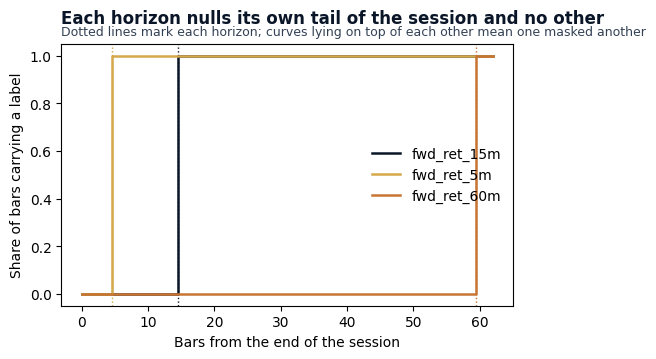

In [15]:
fig, ax = plt.subplots(figsize=FIGSIZE["single"])
for name, colour in PALETTE.items():
    ax.plot(profile["from_end"], profile[name], ds="steps-mid", lw=1.8, c=colour, label=name)
    ax.axvline(HORIZON_BARS[name] - 0.5, color=colour, linestyle=":", lw=1)
ax.set_xlabel("Bars from the end of the session")
ax.set_ylabel("Share of bars carrying a label")
sub = "Dotted lines mark each horizon; curves lying on top of each other mean one masked another"
add_message_title(ax, "Each horizon nulls its own tail of the session and no other", sub)
ax.legend(loc="center right", frameon=False)
show_with_alt(fig, "Non-null label rate by bar position from the end of each trading session.")

## E. Distribution and base rate

What scale is the label, and does it mean the same thing across the panel and across
time? Everything from here through Section G is computed on the development window only,
sealed on the label's **endpoint** rather than on the bar it was observed from: a
decision taken shortly before the holdout still resolves inside it, so a filter on the
observation time looks sealed and is not. The label files keep every row, because the
seal governs what this notebook looks at rather than what it writes.

Each label is sealed on its own endpoint, because they do not resolve together: the
60-minute window closes three quarters of an hour after the 15-minute one opened from
the same bar, so one boundary applied to all three would leave the slowest label
reaching furthest into the holdout. The symbol-session is carried as one `entity` key,
because it is the entity no label may cross and Section F counts overlap within it.

In [16]:
_entity = (pl.col("symbol") + "|" + pl.col("session_date").cast(pl.Utf8)).alias("entity")
dev = {
    name: labels_df.with_columns(
        pl.col("timestamp").shift(-HORIZON_BARS[name]).over(GROUP_COLS).alias("_label_end"),
        _entity,
    )
    .filter(pl.col("_label_end") < HOLDOUT_TS)
    .drop_nulls(name)
    .select(["timestamp", "symbol", "half_spread", "entity", "bar_in_session", name])
    for name in LABEL_NAMES
}
for name in LABEL_NAMES:
    print(f"{name}: {dev[name].height:,} development rows through {dev[name]['timestamp'].max()}")

fwd_ret_15m: 14,370,375 development rows through 2021-06-30 15:44:00
fwd_ret_5m: 14,753,585 development rows through 2021-06-30 15:54:00
fwd_ret_60m: 12,645,930 development rows through 2021-06-30 14:59:00
fwd_dir_15m: 14,370,375 development rows through 2021-06-30 15:44:00


All three horizons go on one axis with identical bins and a logarithmic count axis. The
claim is about shape rather than width: a longer horizon accumulates more variance, so
if the three are the same process observed over different spans the bodies should widen
in proportion to the square root of the horizon while the tails stay heavy throughout.
The axis is symmetric and narrower than any label's range, so rows outside it are counted
below rather than drawn.

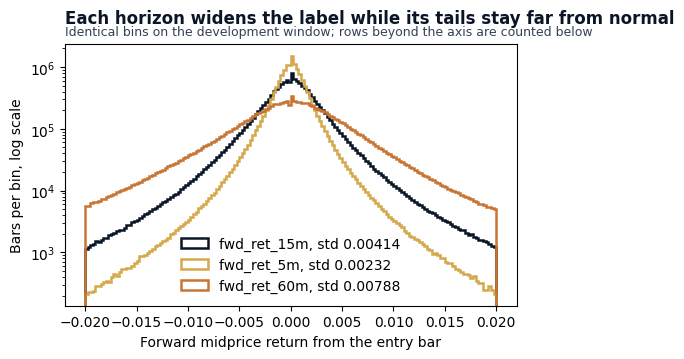

In [17]:
bins = np.linspace(-0.02, 0.02, 161)
primary_std = dev[PRIMARY_LABEL][PRIMARY_LABEL].std()
fig, ax = plt.subplots(figsize=FIGSIZE["single"])
for name, colour in PALETTE.items():
    series = dev[name][name]
    tag = f"{name}, std {series.std():.5f}"
    ax.hist(series.to_numpy(), bins=bins, histtype="step", lw=1.8, color=colour, label=tag)
ax.set_yscale("log")
ax.set_xlabel("Forward midprice return from the entry bar")
ax.set_ylabel("Bars per bin, log scale")
sub = "Identical bins on the development window; rows beyond the axis are counted below"
add_message_title(ax, "Each horizon widens the label while its tails stay far from normal", sub)
ax.legend(loc="lower center", frameon=False)
show_with_alt(fig, "Histograms of the three labels on identical bins, log count axis.")

In [18]:
for name in RETURN_LABELS:
    series = dev[name][name]
    out = series.filter((series < bins[0]) | (series > bins[-1])).len()
    root_h = np.sqrt(HORIZONS[name] / PRIMARY_HORIZON)
    print(
        f"{name}: std {series.std():.6f}, kurtosis {series.kurtosis():.1f}, "
        f"{series.std() / primary_std:.2f}x the primary label against {root_h:.2f} under "
        f"square-root-of-horizon scaling, {out:,} beyond the axis"
    )

fwd_ret_15m: std 0.004142, kurtosis 298.8, 1.00x the primary label against 1.00 under square-root-of-horizon scaling, 63,228 beyond the axis
fwd_ret_5m: std 0.002324, kurtosis 1147.8, 0.56x the primary label against 0.58 under square-root-of-horizon scaling, 10,204 beyond the axis
fwd_ret_60m: std 0.007884, kurtosis 86.0, 1.90x the primary label against 2.00 under square-root-of-horizon scaling, 325,342 beyond the axis


The label is what a trade earns before costs, and the spread is most of what it pays.
Both are in the same units, so they belong on the same axis: the curves are the
distribution of the absolute move at each horizon, and the vertical line is the spread a
**round trip** crosses - twice the half-spread, because the position is opened and closed
- on the same bars.

The comparison is not the case study's answer, it is the reason the case study is worth
running. A move larger than the spread is necessary for the horizon to be tradable and
nowhere near sufficient: what a strategy earns is the move times how often it gets the
direction right, and Section G measures how little of that is on offer here.

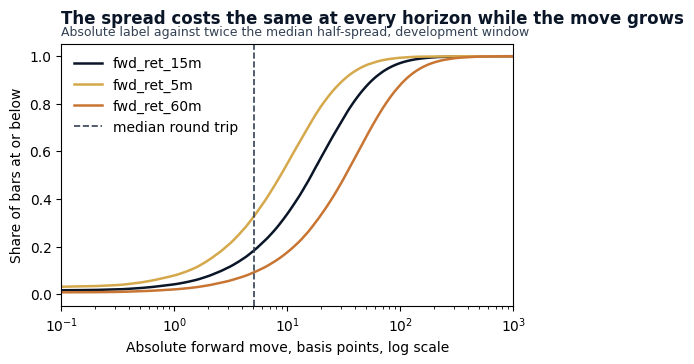

In [19]:
round_trip = 2 * dev[PRIMARY_LABEL]["half_spread"].median() * 10_000
fig, ax = plt.subplots(figsize=FIGSIZE["single"])
for name, colour in PALETTE.items():
    moves = (dev[name][name].abs() * 10_000).sort().to_numpy()
    ax.plot(moves, np.arange(1, len(moves) + 1) / len(moves), lw=1.8, color=colour, label=name)
ax.axvline(round_trip, color=COLORS["neutral"], ls="--", lw=1.2, label="median round trip")
ax.set_xscale("log")
ax.set_xlim(0.1, 1000)  # below a tenth of a bp the move is a stale quote, not a move
ax.set_xlabel("Absolute forward move, basis points, log scale")
ax.set_ylabel("Share of bars at or below")
sub = "Absolute label against twice the median half-spread, development window"
add_message_title(ax, "The spread costs the same at every horizon while the move grows", sub)
ax.legend(loc="upper left", frameon=False)
show_with_alt(fig, "Empirical CDF of absolute moves per horizon against the median round trip.")

In [20]:
for name in RETURN_LABELS:
    frame, moved = dev[name], dev[name][name].abs()
    clears = (moved > 2 * frame["half_spread"]).mean()
    print(
        f"{name}: median absolute move {moved.median() * 10_000:.2f}bps against a "
        f"{2 * frame['half_spread'].median() * 10_000:.2f}bps round trip, {clears:.1%} clears it"
    )

fwd_ret_15m: median absolute move 16.34bps against a 5.03bps round trip, 79.3% clears it
fwd_ret_5m: median absolute move 8.74bps against a 4.98bps round trip, 65.3% clears it


fwd_ret_60m: median absolute move 32.75bps against a 5.25bps round trip, 88.8% clears it


Chapter 7.2 asks for the base rate to be tracked through time. The direction label is
where that question has an answer: its three classes are cut at a fixed band, so their
proportions are free to move, and a classifier trained on one regime and scored in
another is only comparable if they do not move much. The flat class is the interesting
one - it is the share of the session where nothing happens that is worth paying for.

In [21]:
monthly = (
    dev[DIRECTION_LABEL]
    .with_columns(pl.col("timestamp").dt.truncate("1mo").alias("month"))
    .group_by("month")
    .agg([(pl.col(DIRECTION_LABEL) == k).mean().alias(str(k)) for k in (-1, 0, 1)])
    .sort("month")
)

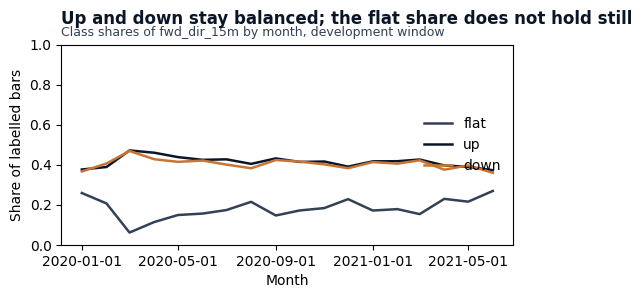

flat: 0.181 of labelled bars, ranging 0.061 to 0.268 across months
up: 0.414 of labelled bars, ranging 0.372 to 0.471 across months
down: 0.404 of labelled bars, ranging 0.359 to 0.468 across months


In [22]:
classes = {"0": "flat", "1": "up", "-1": "down"}
shades = (COLORS["neutral"], COLORS["blue"], COLORS["copper"])
fig, ax = plt.subplots(figsize=FIGSIZE["single_wide"])
for (key, tag), colour in zip(classes.items(), shades):
    ax.plot(monthly["month"], monthly[key], lw=1.8, color=colour, label=tag)
ax.set_ylim(0, 1)
ax.set_xticks(monthly["month"].to_list()[::4])
ax.set_xlabel("Month")
ax.set_ylabel("Share of labelled bars")
sub = f"Class shares of {DIRECTION_LABEL} by month, development window"
add_message_title(ax, "Up and down stay balanced; the flat share does not hold still", sub)
ax.legend(loc="center right", frameon=False)
show_with_alt(
    fig, "Monthly class shares of the ternary direction label across the development window."
)

for key, tag in classes.items():
    lo, hi = monthly[key].min(), monthly[key].max()
    share = (dev[DIRECTION_LABEL][DIRECTION_LABEL] == int(key)).mean()
    print(f"{tag}: {share:.3f} of labelled bars, ranging {lo:.3f} to {hi:.3f} across months")

On the development window the primary label has a standard deviation of 0.004142, against
0.002324 for the 5-minute label and 0.007884 for the 60-minute one - 0.56x and 1.90x the
primary, against the 0.58x and 2.00x square-root-of-horizon scaling implies, so the shorter
horizon scales as that rule predicts and the longer one falls a little short of it. None of
the three is remotely normal: kurtosis runs from 86.0 at 60 minutes to 1147.8 at 5, so the
shorter the horizon the more of its variance sits in rare bars.

Against cost, the median absolute move is 8.74bps at 5 minutes, 16.34bps at 15 and 32.75bps
at 60, while the median round trip is 4.98, 5.03 and 5.25bps on the same bars - the move
roughly doubles with each step up in horizon and the spread does not move at all. The share
of bars whose move clears that round trip climbs from 65.3% to 79.3% to 88.8%. Cut at the
5bps friction floor, the direction label splits 0.414 up, 0.404 down and 0.181 flat, and
while up and down hold between 0.372-0.471 and 0.359-0.468 across months, the flat share
runs from 0.061 to 0.268.

## F. Overlap and effective sample size

Sampling a multi-bar label at every bar makes consecutive rows share most of their
forward window, so the row count overstates the evidence. Two measurements answer that in
different units: how fast the overlap decays, and what the rows are worth once it is
priced in. Both are counted on the bar position within the session, which is the grid the
horizon was converted into, and both treat the symbol-session as the entity, because a
window cannot be concurrent with one on the other side of an overnight gap.

What a label consumes is return intervals, and it consumes one fewer than its horizon in
bars: entering a bar after the decision and leaving at the horizon spans the moves between
those two prices, not the move into the entry. Consecutive rows share all but one of those
intervals, so the decay reads as a straight line falling by one interval per lag.
The longest label does not stop at zero when it gets there but keeps going negative, and
that is a property of the session rather than of the label - a one-hour window is a fifth of
a trading day, so each session holds few independent windows, and subtracting the session's
own mean from so few of them forces what is left to correlate negatively at long lags.

In [23]:
max_lag = max(HORIZON_BARS[name] for name in RETURN_LABELS) + 4
acf = {
    name: panel_autocorrelation(
        dev[name], name, max_lag=max_lag, bar_col="bar_in_session", entity_col="entity"
    )
    for name in RETURN_LABELS
}

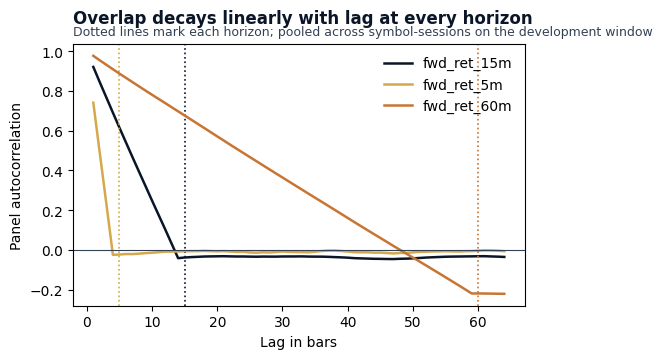

In [24]:
fig, ax = plt.subplots(figsize=FIGSIZE["single"])
lags = np.arange(1, max_lag + 1)
for name, colour in PALETTE.items():
    ax.plot(lags, acf[name], lw=1.8, color=colour, label=name)
    ax.axvline(HORIZON_BARS[name], color=colour, linestyle=":", lw=1.2)
ax.axhline(0, color=COLORS["neutral"], lw=0.8)
ax.set_xlabel("Lag in bars")
ax.set_ylabel("Panel autocorrelation")
sub = "Dotted lines mark each horizon; pooled across symbol-sessions on the development window"
add_message_title(ax, "Overlap decays linearly with lag at every horizon", sub)
ax.legend(loc="upper right", frameon=False)
show_with_alt(fig, "Panel autocorrelation of each forward-return label against lag in bars.")

In [25]:
for name in RETURN_LABELS:
    h_bars, spans = HORIZON_BARS[name], HORIZON_BARS[name] - 1
    n_rows, n_eff = effective_sample_size(
        dev[name], horizon=spans, bar_col="bar_in_session", entity_col="entity"
    )
    print(
        f"{name}: N={n_rows:,}, N_eff={n_eff:,.0f}, ratio {n_eff / n_rows:.4f} against "
        f"{1 / spans:.4f} for {spans} intervals overlapping fully; autocorrelation "
        f"{acf[name][0]:.3f} at lag one and {acf[name][h_bars - 1]:.3f} at its horizon"
    )

fwd_ret_15m: N=14,370,375, N_eff=1,062,039, ratio 0.0739 against 0.0714 for 14 intervals overlapping fully; autocorrelation 0.920 at lag one and -0.038 at its horizon


fwd_ret_5m: N=14,753,585, N_eff=3,717,137, ratio 0.2519 against 0.2500 for 4 intervals overlapping fully; autocorrelation 0.741 at lag one and -0.023 at its horizon


fwd_ret_60m: N=12,645,930, N_eff=252,009, ratio 0.0199 against 0.0169 for 59 intervals overlapping fully; autocorrelation 0.976 at lag one and -0.219 at its horizon


The primary label's 14,370,375 development rows carry 1,062,039 effective observations, a
ratio of 0.0739 against the 0.0714 that fourteen fully overlapping intervals imply; the
5-minute label's 14,753,585 rows carry 3,717,137 at 0.2519 against 0.2500, and the
60-minute label's 12,645,930 carry 252,009 at 0.0199 against 0.0169. Each sits above its
reference because a session end closes an overlap early, and the longest label sits
furthest above it because the session ends most often relative to its window. Fourteen
million rows are worth about a million: the row count overstates the evidence by roughly
the number of intervals each label spans.

Autocorrelation falls from 0.920 at lag one to -0.038 at lag fifteen for the primary label
and from 0.741 to -0.023 at lag five for the fast one. The 60-minute label falls from 0.976
to -0.219 at lag sixty, crossing zero around lag fifty. The purge gap a fold needs is set by
the forward window itself, not by any of these counts.

## G. Baseline floor

One signal against the primary label on the sealed development window, with no feature
engineering: the trailing return over the same span as the label looks forward. If the
order flow of the last fifteen minutes carries information about the next fifteen, the
simplest form it can take is that the move continues or that it reverses, and Chapter 8's
features have to beat whatever that is worth before they have earned their place.

The information coefficient is the cross-sectional rank correlation across the symbols
priced at each decision minute, averaged over minutes, which is the quantity a ranking
model is scored on. The minimum cross-section is half the median rather than a bare
count, so it means the same thing on a universe of another size. The standard error is
HAC-adjusted: consecutive decision minutes share fourteen of their fifteen bars of
outcome, and a naive statistic would count each of them as fresh evidence.

In [26]:
_h = HORIZON_BARS[PRIMARY_LABEL]
_trailing = pl.col("mid_close") / pl.col("mid_close").shift(_h).over(GROUP_COLS) - 1
baseline = (
    labels_df.with_columns(
        _trailing.alias("trailing_return"),
        pl.col("timestamp").shift(-_h).over(GROUP_COLS).alias("_label_end"),
    )
    .filter(pl.col("_label_end") < HOLDOUT_TS)
    .drop_nulls([PRIMARY_LABEL, "trailing_return"])
)
min_obs = int(baseline.group_by("timestamp").len()["len"].median() // 2)

ic = cross_sectional_ic_series(
    baseline,
    baseline,
    pred_col="trailing_return",
    ret_col=PRIMARY_LABEL,
    date_col="timestamp",
    entity_col="symbol",
    min_obs=min_obs,
).sort("timestamp")  # HAC autocovariances are meaningless over a permutation of time
stats = compute_ic_hac_stats(ic, ic_col="ic", label_horizon=_h)

In [27]:
print(f"Baseline: trailing {PRIMARY_HORIZON} return against {PRIMARY_LABEL}")
print(f"  {baseline.height:,} rows, minimum cross-section {min_obs} symbols")
print(
    f"  decision minutes scored {ic.height:,}, mean IC {stats['mean_ic']:.5f}, "
    f"HAC t {stats['t_stat']:.2f} on {stats['effective_lags']} Bartlett lags, "
    f"naive t {stats['naive_t_stat']:.2f}, p {stats['p_value']:.3g}"
)

Baseline: trailing 0:15:00 return against fwd_ret_15m
  13,795,560 rows, minimum cross-section 51 symbols
  decision minutes scored 135,720, mean IC -0.00798, HAC t -6.02 on 19 Bartlett lags, naive t -16.78, p 1.74e-09


The trailing 15-minute return earns a mean information coefficient of -0.00798 against the
primary label, over 135,720 scored decision minutes drawn from 13,795,560 rows on a
cross-section of at least 51 symbols. The sign is negative, so on this universe the recent
move tends to give part of itself back rather than continue.

The Newey-West rule picks 19 Bartlett lags and returns a t-statistic of -6.02 against a
naive -16.78, so pricing in the overlap cuts the apparent evidence by nearly two thirds -
and what is left is still far from zero, at p 1.74e-09. That is the floor: a feature that
ranks the cross-section no better than the last quarter-hour of price has added nothing.
It is a floor on ranking, not on profit - a coefficient of this size is small next to the
round trip Section E priced, which is the tension the rest of the case study works through.

## H. Artifacts and the audit record

Each label is written with a digest sidecar beside it, recording the content digest of
the values written, the row count, the key columns, the notebook that wrote it, and the
digest of the price data it was built from. That last field is what ties a label to its
data vintage: without it a re-run against a refreshed download is indistinguishable from
a re-run against this one.

Each file is written from its own null set, so the three horizons carry three different
row counts. The folds that train models are derived per label by
`case_studies/utils/cv_window.py` from `config/setup.yaml` and the timeline of the label
parquet written here, so which rows land in these files is what sets where the fold
boundaries fall.

In [28]:
readers = {PRIMARY_LABEL: "03_financial_features.py, as the label it names directly"}
for name in LABEL_NAMES:
    record = write_artifact(
        labels_df.select(["timestamp", "symbol", name]).drop_nulls(),
        LABELS_DIR / f"{name}.parquet",
        keys=["timestamp", "symbol"],
        written_by="02_labels",
        inputs={"market_data": MARKET_DATA_DIGEST},
    )
    print(f"{name}.parquet: {record['n_rows']:,} rows, digest {record['digest']}")

fwd_ret_15m.parquet: 19,142,250 rows, digest c16a1a1fbb75e9ca


fwd_ret_5m.parquet: 19,652,710 rows, digest 684c84ef0ffb38e1


fwd_ret_60m.parquet: 16,845,180 rows, digest 7704b58a2f2adda5


fwd_dir_15m.parquet: 19,142,250 rows, digest fc831892a9a67382


The record Chapter 7.2 requires to close a label definition, one row per label, built
from the values computed above rather than written by hand.

In [29]:
print("\nLabel audit record")
for name in LABEL_NAMES:
    horizon, h_bars = HORIZONS[name], HORIZON_BARS[name]
    series = dev[name][name]
    scale = (
        f"mean {series.mean():+.6f}, std {series.std():.6f}"
        if name in RETURN_LABELS
        else ", ".join(f"{k}: {(series == k).mean():.3f}" for k in (-1, 0, 1))
    )
    print(
        f"\n{name}\n  anchor       quote midpoint one bar after the decision bar"
        f"\n  horizon      {horizon}, which is {h_bars} bars on this grid"
        f"\n  resolution   fixed at t+{horizon}; the closing NBBO quote breaks the within-bar tie"
        f"\n  overlap      {h_bars - 2} of its {h_bars - 1} return intervals, with the next row"
        f"\n  base rate    {scale}"
        f"\n  consumed by  {readers.get(name, 'the model stages, as a variant')}"
    )


Label audit record

fwd_ret_15m
  anchor       quote midpoint one bar after the decision bar
  horizon      0:15:00, which is 15 bars on this grid
  resolution   fixed at t+0:15:00; the closing NBBO quote breaks the within-bar tie
  overlap      13 of its 14 return intervals, with the next row
  base rate    mean +0.000021, std 0.004142
  consumed by  03_financial_features.py, as the label it names directly

fwd_ret_5m
  anchor       quote midpoint one bar after the decision bar
  horizon      0:05:00, which is 5 bars on this grid
  resolution   fixed at t+0:05:00; the closing NBBO quote breaks the within-bar tie
  overlap      3 of its 4 return intervals, with the next row
  base rate    mean +0.000004, std 0.002324
  consumed by  the model stages, as a variant

fwd_ret_60m
  anchor       quote midpoint one bar after the decision bar
  horizon      1:00:00, which is 60 bars on this grid
  resolution   fixed at t+1:00:00; the closing NBBO quote breaks the within-bar tie
  overlap     

## Key takeaways

1. **Write the label as an execution convention, then resolve the exit by time.** Naming
   the two prices a trade crosses - one bar after the decision, and again at the horizon -
   fixes what the number means; finding the exit by timestamp rather than by counting rows
   is what keeps it meaning that when a bar is missing.
2. **Measure the bar grid before converting a declared horizon into bars.** A 15-row shift
   is a 15-minute return only on a one-minute grid, and a loader that returns a raw
   partition promises no such thing. Measure the spacing, require the horizon to be a
   whole number of bars, and the conversion stops being an assumption.
3. **Write every label from its own null set.** Dropping rows on the primary label before
   saving the others silently truncates the shorter horizons at the session close, and the
   row counts look plausible because the file is still large.
4. **Seal a diagnostic on the label's endpoint.** A decision taken before the holdout whose
   outcome resolves inside it is a holdout row, so the usable boundary is the boundary
   minus the horizon, counted within the session.
5. **A row count overstates the evidence when forward windows overlap.** The effective
   count says by how much, and the HAC standard error is what stops that overlap from
   inflating a t-statistic - here by a factor of nearly three.

**Known limitations.** The midprice is not a fill: a marketable order crosses the spread,
and the round trip charted in Section E is the quoted spread rather than a measured
execution cost - it carries no commission, no market impact and no queue position, so it
is a floor on what trading costs. It is also the spread quoted at the decision bar, doubled,
rather than the two spreads actually crossed at the entry and exit bars, so it prices the
round trip at the moment the decision is taken and not at the moments it is filled. The universe is the fixed NASDAQ-100 membership list
`setup.yaml` declares, not a
point-in-time index reconstruction, so a name that joined or left mid-sample is present
throughout. The flat band is a single constant across every symbol and every regime,
where the spread it stands for is neither. The baseline is one signal at one horizon.

**Next**: `03_financial_features.py` builds the order-flow, liquidity and volatility
features and evaluates them against these labels.